# Inpainting with GPR-LIM

June, 2026

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import glob
import sys

sys.path.append('/Users/alliswell48/radio_gpr_work/shao/gprlim')
import gprlim
from gprlim import kernels

from pyuvdata import UVData
import bayeslim as ba

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
sys.path.append('../')
import gp_utils

In [4]:
import gpytorch
gpytorch.settings.max_cholesky_size._set_value(1_000)

In [5]:
torch.set_default_dtype(torch.float64)
device = 'cpu'

In [6]:
#总数据：(Nbls, Ntimes, Nfreq, Npol)=(242,1600,600,4)
#这里的file (110,1600,600,4)，thus:110*(110+1)/2= 6105 个baseline，200组（每组位置矢量相同）
#(Nbls, Ntimes, Nfreq, Npol)=(1,200,400,1)

In [7]:
# specify frequency channels
# by default, use equal to or less than 200 time integrations
# by default, use about 300-400 frequency channels
freq_chans = range(200, 600)
time_ints = range(300, 500)

# pick a representative baseline to load and model (start with 0)
bl = (0, 1)

In [8]:
# specify data
dfile = 'gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5' #需要自己产生redundant baselibne
#dfile = sorted(glob.glob('../zen.h6c_idr2_validation.24582*.sum.coupled.h5')) #已经自动包含redundant baselibne

In [9]:
# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=['ee'], time_ints=time_ints, freq_chans=freq_chans,
) #取auto (0,0) baselines
autocorr = vd.data[0,0]  #不是取baselines,是去掉前两维-》[1, 1, 1, 200, 400]->[1, 200, 400] =(baselines,Ntimes, Nfreq)

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']
# 它的meta文件:包含ant所有的1/4,  6105 baselines;分为20组（每组位置矢量相同；
#但实际上‘zen.h6c_idr2_validation.sum.uvh5'只含有(0,n)代表组基线数据
#而上面的load_uvdata( bls=[(0, 0)])只加载了一组

# get noise standard deviation
#meta['times']:day->s
#meta['freqs']:Hz
#formla sigma^2 = Vii * Vjj / Delta t / Delta nu.
#=>sigma (noise standard deviation)= Vjj / np.sqrt(Delta t / Delta nu)
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

# load redundant data

load a single redundant baseline

In [10]:
# pick a representative baseline to load and model (start with 0)
#bl = (0, 2)

# this gets the index in the redundant set that this baseline falls in
red_ind = np.where([bl in red for red in reds])[0][0] #bl 属于第几组
bls = reds[red_ind][:] #该组所有成员
bl_vec = antp[bls[0][1]] - antp[bls[0][0]] #bls是该组 所有baselines的 位置矢量bls,选bls[0]->bl = (0, 2)
bl_len = bl_vec.norm()  #bl = (0, 2) 的baselines长度

In [11]:
# load single baseline data
#bl = (0, 2)
#(Nbls, Ntimes, Nfreq, Npol)=(1,200,400,1)
vd, meta = gp_utils.load_uvdata(
    dfile,
    bls=bls,
    time_ints=time_ints,
    freq_chans=freq_chans,
    pols=['ee'],
    device=device,
)
freqs = meta['freqs'] / 1e6   #Hz-> GHz
lsts = meta['lsts']  #day
times = (meta['times'] - meta['times'][0]) * 24 * 3600  #day->s
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']   #所有baselibe编号；包括redudant，虽然只有(0,n)的baseline有数据，其他没有

Antenna pair (1, 2) does not have any data associated with it.
Antenna pair (2, 3) does not have any data associated with it.
Antenna pair (3, 4) does not have any data associated with it.
Antenna pair (4, 5) does not have any data associated with it.
Antenna pair (5, 6) does not have any data associated with it.
Antenna pair (6, 7) does not have any data associated with it.
Antenna pair (7, 8) does not have any data associated with it.
Antenna pair (8, 9) does not have any data associated with it.
Antenna pair (9, 10) does not have any data associated with it.
Antenna pair (11, 12) does not have any data associated with it.
Antenna pair (12, 13) does not have any data associated with it.
Antenna pair (13, 14) does not have any data associated with it.
Antenna pair (14, 15) does not have any data associated with it.
Antenna pair (15, 16) does not have any data associated with it.
Antenna pair (16, 17) does not have any data associated with it.
Antenna pair (17, 18) does not have any da

In [12]:
inflate_data = True
if inflate_data and vd.Nbls == 1:
    vd = vd.inflate_by_redundancy(bls=reds[red_ind]) #reds[red_ind]是bl = (0, 2)对应的组的所有redundant成员
    
#[1, 1, 1, 200, 400]->[1, 1, 90, 200, 400]    
    

In [13]:
add_noise = False
if add_noise:
    vd.data += torch.randn_like(vd.data) * noise_amp * 1e-3

In [14]:
# look at how large the data is
print("size of data in MB: {:.1f}".format(vd.data.nbytes/1e6))

size of data in MB: 128.0


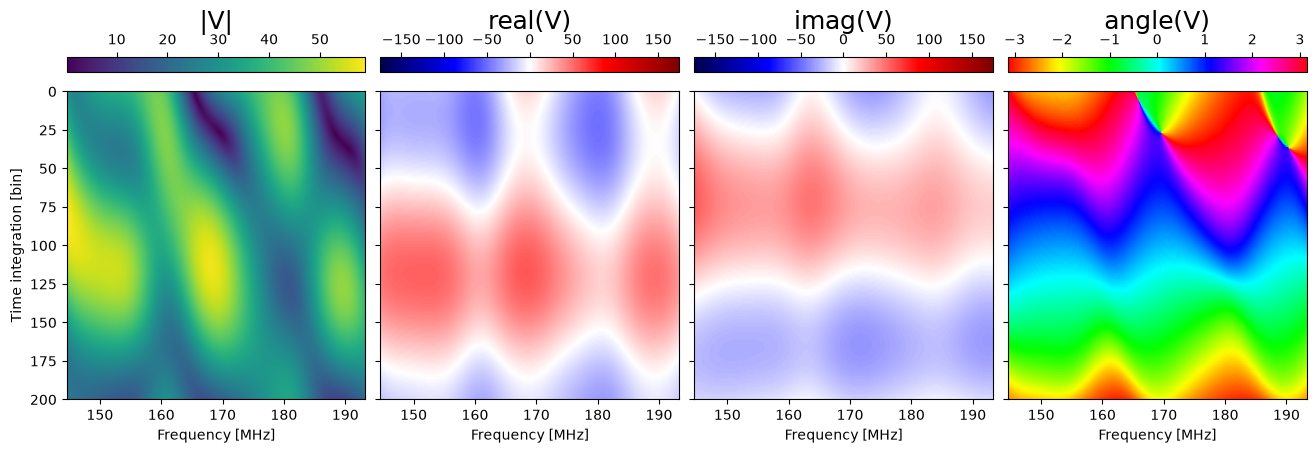

In [15]:
# plot the data (called a waterfall)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)
dstd = vd.data.std()

#[1, 1, 90, 200, 400] 
#vd.data[0,0,0] 意思是[0,0,0, 200, 400] 

# visibility amplitude (abs)
cax = axes[0].imshow(vd.data[0,0,0].abs(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_title("|V|", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[0], location='top');
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time integration [bin]');

# visibility real
cax = axes[1].imshow(vd.data[0,0,0].real, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[1].set_title("real(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[1], location='top');
axes[1].set_xlabel('Frequency [MHz]'); axes[1].set_yticklabels([])

# visibility imag
cax = axes[2].imshow(vd.data[0,0,0].imag, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[2].set_title("imag(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[2], location='top');
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_yticklabels([]);

# visibility phase
cax = axes[3].imshow(vd.data[0,0,0].angle(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='hsv')
axes[3].set_title("angle(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[3], location='top');
axes[3].set_xlabel('Frequency [MHz]'); axes[3].set_yticklabels([]);

In [16]:
from bayeslim.fft import FFT
# vd.data.shape [1, 1, 90, 200, 400]
FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)  
FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)  
# time-> unit 1000 second=> fft ->fringe rate: unit: mHz

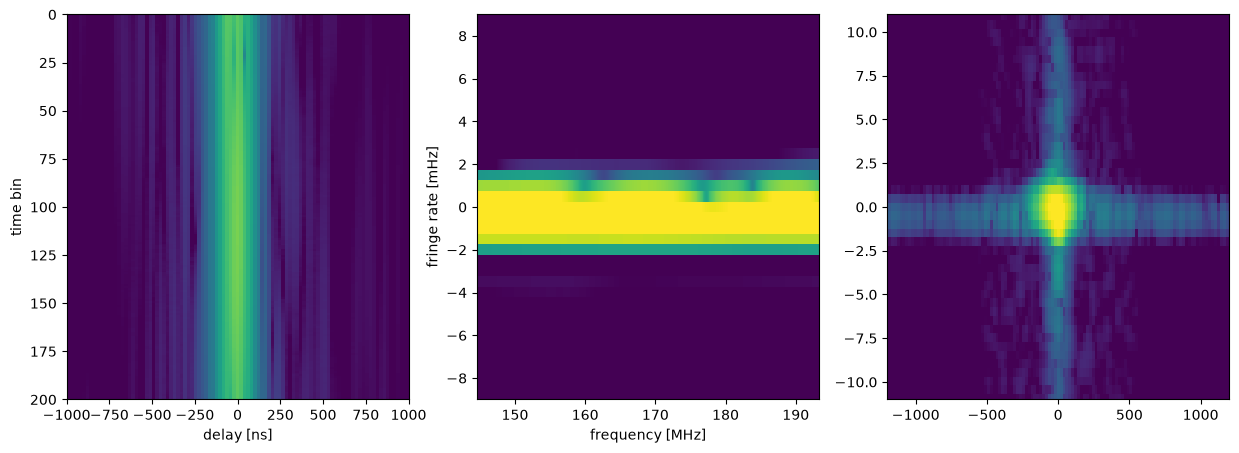

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#[1, 1, 90, 200, 400]-> 取baseline 0；[1, 1, , 200, 400]
#pytorch: [ 200, 400] 从右边开始broadcasting=> [ 1,1,200, 400]，所以ndim=2也可以
axes[0].imshow(FT1(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], Ntimes, 0])
axes[0].set_xlim(-1000, 1000); axes[0].set_xlabel('delay [ns]'); axes[0].set_ylabel('time bin')

axes[1].imshow(FT2(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=0, vmax=3,
               extent=[freqs[0], freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_ylim(-9, 9); axes[1].set_xlabel('frequency [MHz]'); axes[1].set_ylabel('fringe rate [mHz]')

axes[2].imshow(FT1(FT2(vd.data))[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11);

# 1. Fractional residual  $100  \frac{\left||V_{\rm data}(\tau)| - |V_{\rm inpainted}(\tau)|\right|}{|V_{\rm data}(\tau)|} [\%]$ 



In [18]:
import os

bl_name = f"bl_{bl[0]}_{bl[1]}"
freq_time_name = (
    f"freq_{freq_chans.start}_{freq_chans.stop}_"
    f"time_{time_ints.start}_{time_ints.stop}"
)

save_dir = os.path.join(
    "inpaint_results",
    bl_name,
    freq_time_name,
)

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_real.pt
Flag 1: real
flags shape: torch.Size([1, 200, 400])


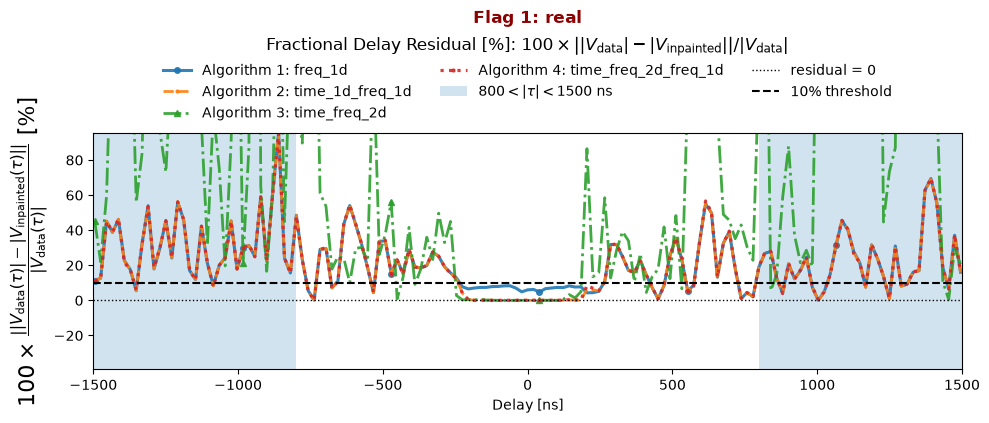

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_narrowband_full_time.pt
Flag 2: narrowband_full_time
flags shape: torch.Size([1, 200, 400])


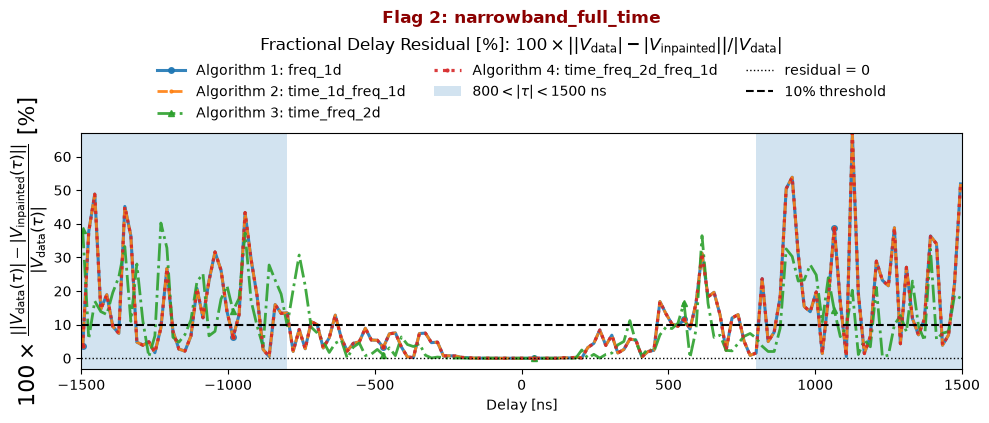

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_wideband_full_time.pt
Flag 3: wideband_full_time
flags shape: torch.Size([1, 200, 400])


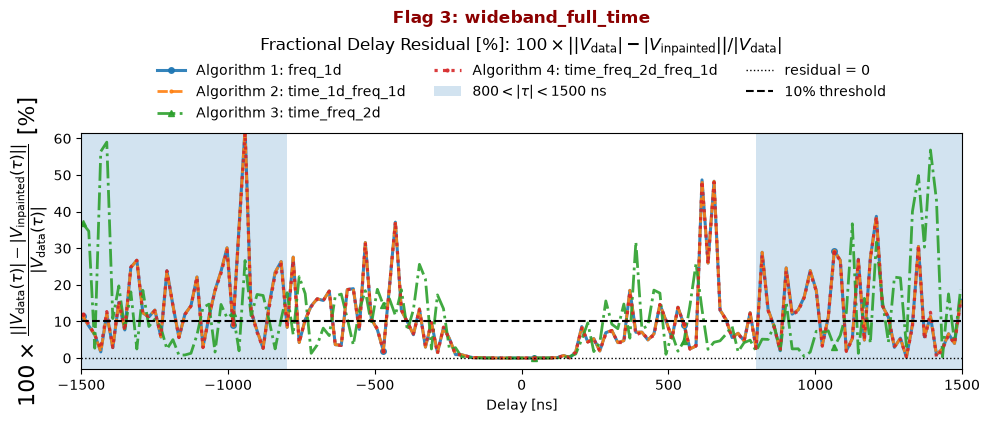

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_ultraband_short_time.pt
Flag 4: ultraband_short_time
flags shape: torch.Size([1, 200, 400])


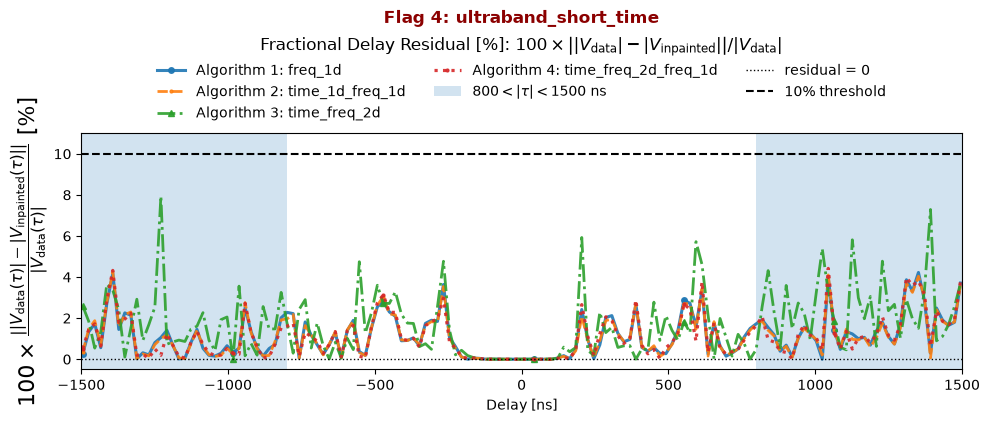

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_fullband_short_time.pt
Flag 5: fullband_short_time
flags shape: torch.Size([1, 200, 400])


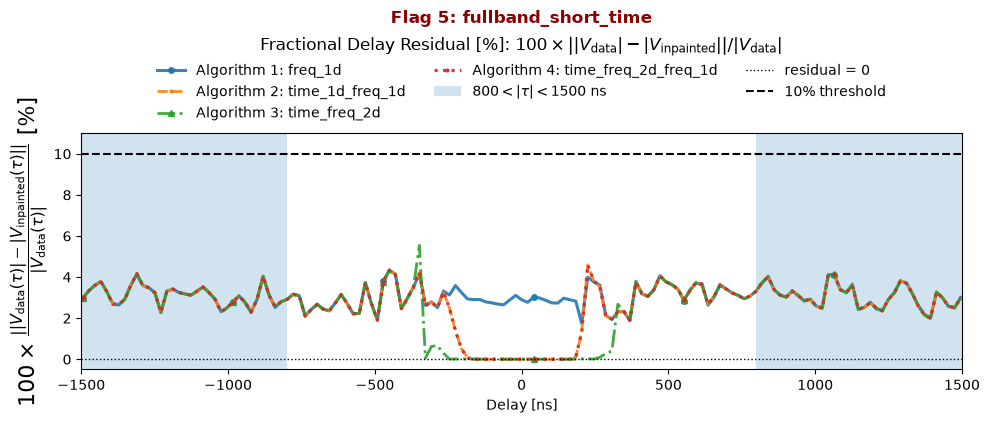

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_narrowband_short_time.pt
Flag 6: narrowband_short_time
flags shape: torch.Size([1, 200, 400])


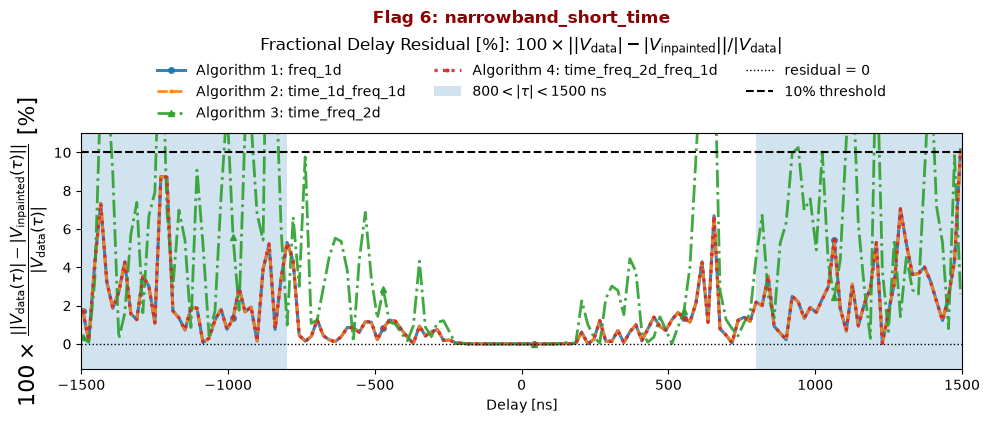

Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_narrowband_intermittent.pt
Flag 7: narrowband_intermittent
flags shape: torch.Size([1, 200, 400])


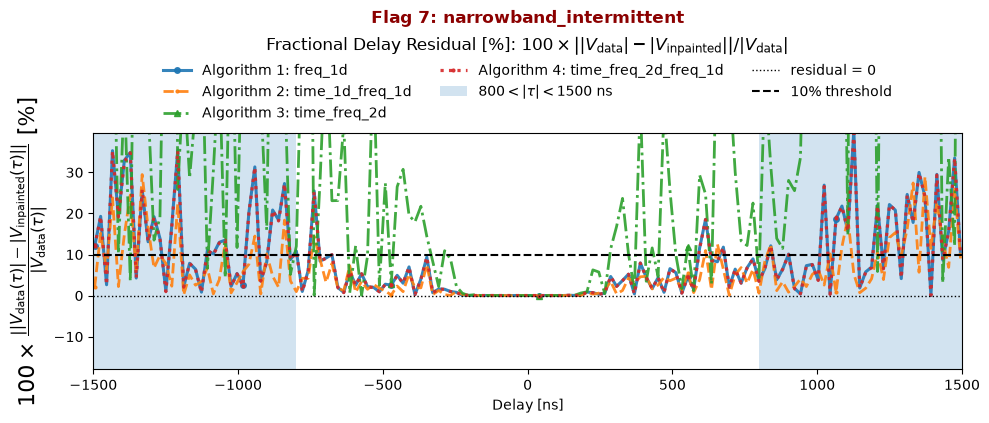

In [20]:
import os
import torch
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


# ==================================================
# 0. Helper: title style
# ==================================================

def add_flag_title(ax, flag_id, flag_name, subtitle, y=1.32):
    ax.text(
        0.5,
        y,
        f"Flag {flag_id}: {flag_name}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        color="darkred",
        fontsize=12,
        fontweight="bold",
    )

    ax.text(
        0.5,
        y - 0.12,
        subtitle,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        color="black",
        fontsize=12,
    )


# ==================================================
# 1. Algorithms to compare
# ==================================================

Algorithm_names = [
    "freq_1d",
    "time_1d_freq_1d",
    "time_freq_2d",
    "time_freq_2d_freq_1d",
]

flag_types_all = [
    ["real"],
    ["narrowband_full_time"],
    ["wideband_full_time"],
    ["ultraband_short_time"],
    ["fullband_short_time"],
    ["narrowband_short_time"],
    ["narrowband_intermittent"],
]


# ==================================================
# 1.1 Plot styles
# ==================================================

linestyles = ["-", "--", "-.", ":"]
markers = ["o", ".", "^", "."]
linewidths = [2.2, 2.0, 2.0, 2.3]
markevery = 25


# ==================================================
# 1.2 Store metric tables
# ==================================================

# Table 1:
# average metric in 800 < |tau| < 1500 ns
metric_table = []

# Table 2:
# strict whole-region test:
# every point in 800 < |tau| < 1500 ns must be within 10%
range_pass_table = []


# ==================================================
# 2. Loop over flag cases
# ==================================================

for flag_id, flag_types in enumerate(flag_types_all, start=1):

    flag_name = "+".join(flag_types)
    save_path = os.path.join(save_dir, f"inpaint_{flag_name}.pt")

    result_this_flag = torch.load(save_path, map_location="cpu")

    flags = result_this_flag["flags"].to(device)

    print("Loaded:", save_path)
    print(f"Flag {flag_id}: {flag_name}")
    print("flags shape:", flags.shape)

    # --------------------------------------------------
    # 2.1 Coherent time average
    # --------------------------------------------------
    avg_times = ba.utils.split_into_groups(
        torch.arange(Ntimes),
        Nelem=50,
    )

    # Original data
    vd_avg = vd.time_average(
        avg_times,
        rephase=True,
        inplace=False,
    )

    # Original data with flagged pixels removed
    vd_flg = vd * ~flags

    vd_flg_avg = vd_flg.time_average(
        avg_times,
        wgts=1 / (flags * 1e5 + 1e0),
        rephase=True,
        inplace=False,
    )

    # ==================================================
    # 3. Fractional absolute delay residual [%]
    # ==================================================

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    # --------------------------------------------------
    # 3.1 Original data delay spectrum
    # --------------------------------------------------
    data_delay = FT1(vd_avg.data[0, 0].mean(0))[:].abs().mean(0)

    # Plot range: -1500 < tau < 1500 ns
    plot_mask = (FT1.freqs > -1500) & (FT1.freqs < 1500)

    # Metric range: 800 < |tau| < 1500 ns
    metric_mask = (FT1.freqs.abs() > 800) & (FT1.freqs.abs() < 1500)

    tau_plot = FT1.freqs[plot_mask]
    data_delay_plot = data_delay[plot_mask]

    # --------------------------------------------------
    # 3.2 Loop over algorithms
    # --------------------------------------------------
    for Algorithm_id, Algorithm_name in enumerate(Algorithm_names, start=1):

        inp_y = result_this_flag["inpaint"][Algorithm_name]["inp_y"].to(device)

        vd_inp = vd.copy(copydata=True)
        vd_inp.data = inp_y[None, None]

        vd_inp_avg = vd_inp.time_average(
            avg_times,
            rephase=True,
            inplace=False,
        )

        inp_delay = FT1(vd_inp_avg.data[0, 0].mean(0))[:].abs().mean(0)
        inp_delay_plot = inp_delay[plot_mask]

        # --------------------------------------------------
        # Fractional absolute residual over plot range [%]
        # --------------------------------------------------
        frac_residual = 100 * (data_delay_plot - inp_delay_plot).abs() / (
            data_delay_plot + 1e-30
        )

        # --------------------------------------------------
        # Metric over 800 < |tau| < 1500 ns [%]
        # --------------------------------------------------
        data_metric = data_delay[metric_mask]
        inp_metric = inp_delay[metric_mask]

        frac_residual_metric = 100 * (data_metric - inp_metric).abs() / (
            data_metric + 1e-30
        )

        # Average metric
        metric_value = frac_residual_metric.mean().item()
        mean_passes = metric_value <= 10.0

        # Strict whole-region test:
        # every point in 800 < |tau| < 1500 ns must be within 10%
        max_metric_value = frac_residual_metric.max().item()
        range_passes = max_metric_value <= 10.0

        metric_table.append(
            {
                "Flag ID": flag_id,
                "Flag Pattern": flag_name,
                "Algorithm": Algorithm_name,
                "Mean residual [%]": metric_value,
                "Mean test": "Pass" if mean_passes else "Fail",
            }
        )

        range_pass_table.append(
            {
                "Flag ID": flag_id,
                "Flag Pattern": flag_name,
                "Algorithm": Algorithm_name,
                "Max residual [%]": max_metric_value,
                "Strict test": "Pass" if range_passes else "Fail",
            }
        )

        # --------------------------------------------------
        # Plot residual
        # --------------------------------------------------
        style_id = Algorithm_id - 1

        ax.plot(
            tau_plot.detach().cpu(),
            frac_residual.detach().cpu(),
            linestyle=linestyles[style_id],
            marker=markers[style_id],
            markevery=markevery,
            markersize=4,
            linewidth=linewidths[style_id],
            alpha=0.9,
            label=f"Algorithm {Algorithm_id}: {Algorithm_name}",
        )

    # --------------------------------------------------
    # 3.3 Shaded delay regions
    # --------------------------------------------------
    ax.axvspan(
        -1500,
        -800,
        alpha=0.2,
        label=r"$800 < |\tau| < 1500$ ns",
    )

    ax.axvspan(
        800,
        1500,
        alpha=0.2,
    )

    # --------------------------------------------------
    # 3.4 Formatting
    # --------------------------------------------------
    ax.axhline(
        0.0,
        color="k",
        ls=":",
        lw=1,
        label="residual = 0",
    )

    ax.axhline(
        10.0,
        color="black",
        ls="--",
        lw=1.5,
        label="10% threshold",
    )

    ax.set_xlim(-1500, 1500)

    ax.set_xlabel("Delay [ns]")
    ax.set_ylabel(
        r"$100 \times "
        r"\frac{\left||V_{\rm data}(\tau)| - |V_{\rm inpainted}(\tau)|\right|}"
        r"{|V_{\rm data}(\tau)|}$ [%]",
        fontsize=16,
    )

    add_flag_title(
        ax,
        flag_id,
        flag_name,
        subtitle=(
            r"Fractional Delay Residual [%]: "
            r"$100\times\left||V_{\rm data}| - |V_{\rm inpainted}|\right|/|V_{\rm data}|$"
        ),
        y=1.45,
    )

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=3,
        frameon=False,
        fontsize=10,
    )

    # Adaptive lower limit, upper limit capped at 200 but at least 11
    ymin, _ = ax.get_ylim()

    ax.set_ylim(
        ymin,
        min(max(frac_residual.detach().cpu().max().item(), 11), 200),
    )

    plt.tight_layout()
    plt.show()




# 2. Table 2:
##    Entire 800 < |tau| < 1500 ns region must be within 10% (Strict test without averaging)


In [41]:
df_range_pass = pd.DataFrame(range_pass_table)

df_strict_result = df_range_pass.pivot(
    index="Flag Pattern",
    columns="Algorithm",
    values="Strict test",
)

df_strict_max = df_range_pass.pivot(
    index="Flag Pattern",
    columns="Algorithm",
    values="Max residual [%]",
)

# Keep same ordering as input
df_strict_result = df_strict_result.loc[
    ["+".join(flag_types) for flag_types in flag_types_all],
    Algorithm_names,
]

df_strict_max = df_strict_max.loc[
    ["+".join(flag_types) for flag_types in flag_types_all],
    Algorithm_names,
]


def bold_pass_fail(val):
    if val == "Pass":
        return "font-weight: bold"
    return ""


styled_strict_result_table = (
    df_strict_result.style
    .map(bold_pass_fail)
    .set_caption(
        r"Table 1: Strict pass/fail test. "
        r"Every point in $800 < |\tau| < 1500$ ns must be within 10%. "
        r"Bold values pass."
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "14px"),
                ("text-align", "left"),
            ],
        }
    ])
)

display(styled_strict_result_table)

Algorithm,freq_1d,time_1d_freq_1d,time_freq_2d,time_freq_2d_freq_1d
Flag Pattern,,,,
real,Fail,Fail,Fail,Fail
narrowband_full_time,Fail,Fail,Fail,Fail
wideband_full_time,Fail,Fail,Fail,Fail
ultraband_short_time,Pass,Pass,Pass,Pass
fullband_short_time,Pass,Pass,Pass,Pass
narrowband_short_time,Fail,Fail,Fail,Fail
narrowband_intermittent,Fail,Fail,Fail,Fail


# 3. Table 2:
## Mean residual metric in 800 < |tau| < 1500 ns

In [46]:
df_metric = pd.DataFrame(metric_table)

df_mean_pivot = df_metric.pivot(
    index="Flag Pattern",
    columns="Algorithm",
    values="Mean residual [%]",
)

# Keep same ordering as input
df_mean_pivot = df_mean_pivot.loc[
    ["+".join(flag_types) for flag_types in flag_types_all],
    Algorithm_names,
]


def bold_mean_passed_values(val):
    if pd.isna(val):
        return ""

    if val <= 10.0:
        return "font-weight: bold"

    return ""


styled_mean_table = (
    df_mean_pivot.style
    .format("{:.2f}")
    .map(bold_mean_passed_values)
    .set_caption(
        r"Table 2: Mean residual [%] in $800 < |\tau| < 1500$ ns: "
        r"$100 \times "
        r"\left\langle "
        r"\frac{\left||V_{\rm data}(\tau)| - |V_{\rm inpainted}(\tau)|\right|}"
        r"{|V_{\rm data}(\tau)|}"
        r"\right\rangle_{800 < |\tau| < 1500\,{\rm ns}}$."
        r"<br>"
        r"Bold values pass the mean 10% criterion."
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "14px"),
                ("text-align", "left"),
            ],
        }
    ])
)

display(styled_mean_table)

Algorithm,freq_1d,time_1d_freq_1d,time_freq_2d,time_freq_2d_freq_1d
Flag Pattern,,,,
real,27.10,27.09,156.85,27.09
narrowband_full_time,19.13,19.13,15.44,19.13
wideband_full_time,14.58,14.58,14.44,14.44
ultraband_short_time,1.30,1.28,2.18,1.29
fullband_short_time,3.08,3.08,3.08,3.08
narrowband_short_time,2.69,2.69,6.54,2.69
narrowband_intermittent,14.23,9.11,84.03,14.14


# 4. Plot Table 2

Mean residual [%] in $800 < |\tau| < 1500$ ns.


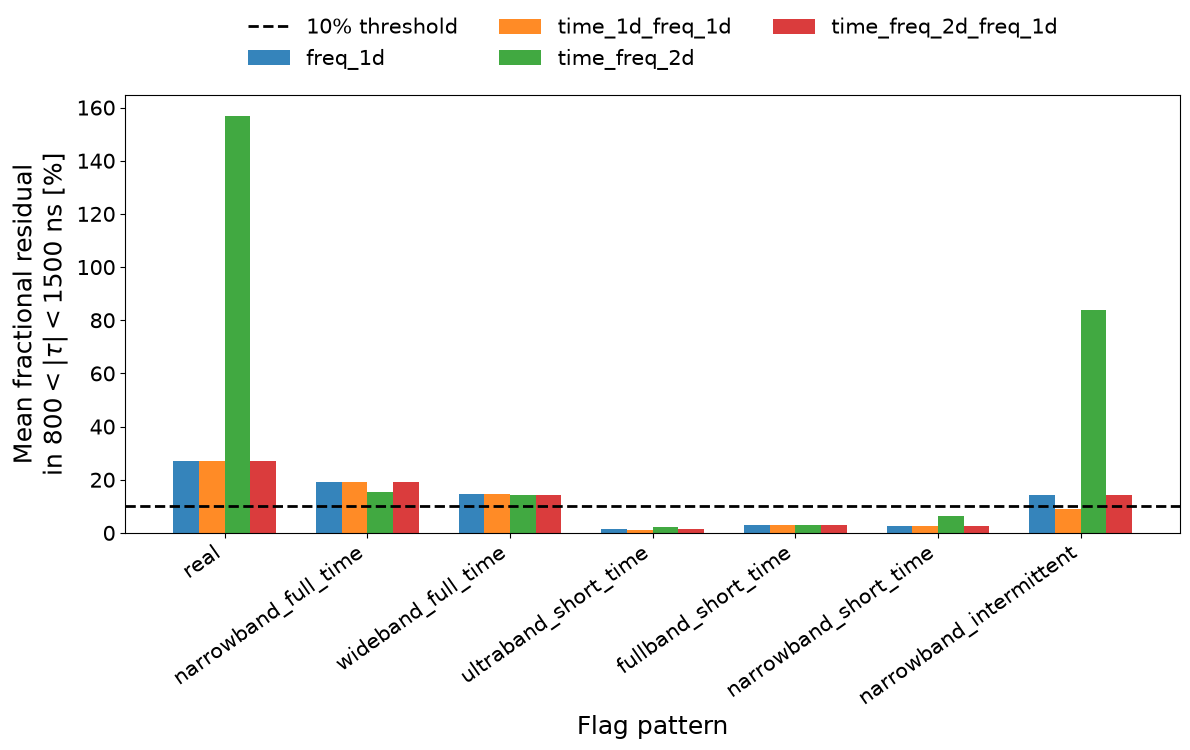

In [34]:
# ==================================================
# 7. Plot mean metric table as a bar figure
# ==================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

x = torch.arange(len(df_mean_pivot.index)).detach().cpu().numpy()
bar_width = 0.18

for i, Algorithm_name in enumerate(Algorithm_names):
    y = df_mean_pivot[Algorithm_name].values

    x_shift = x + (i - 1.5) * bar_width

    bars = ax.bar(
        x_shift,
        y,
        width=bar_width,
        label=Algorithm_name,
        alpha=0.9,
    )

    # Add metric labels on bars
    for bar, val in zip(bars, y):
        fontweight = "bold" if val <= 10.0 else "normal"


# 10% threshold line
ax.axhline(
    10.0,
    color="k",
    linestyle="--",
    linewidth=2.0,
    label="10% threshold",
)

ax.set_xticks(x)
ax.set_xticklabels(
    df_mean_pivot.index,
    rotation=35,
    ha="right",
    fontsize=15,
)

ax.tick_params(axis="y", labelsize=15)
ax.tick_params(axis="x", labelsize=15)

ax.set_ylabel(
    r"Mean fractional residual" "\n"
    r"in $800 < |\tau| < 1500$ ns [%]",
    fontsize=18,
)

ax.set_xlabel(
    "Flag pattern",
    fontsize=18,
)

#ax.grid(axis="y", alpha=0.3)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    ncol=3,
    frameon=False,
    fontsize=15,
)

plt.tight_layout()
plt.show()